In [1]:
# conda activate anndata

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Gene expression vs. eigengene

In [2]:
top_mods_df = pd.read_csv("data/EA/GTEx_frontal_cortex_counts_TMMF_All_247_outliers_removed_mergeParam0.95_subsetCutoff68.768_Modules_Curated_EA_top_Qval_mods.csv")

# ctypes = [
#     "kelley_Endothelial", "kelley_oligo", "AGARWAL_CTX_2020_OPC", "BARRES_ASTROCYTES", 
#     "ZENG_HUMAN_INTERNEURON_MARKERS", "LaMANNO_PERICYTE_MIDBRAIN", "YANG_PFC_2021_L4_EXCITATORY_NEURON"
# ]

# top_mods_df3 = top_mods_df3[top_mods_df3['Cell_type'].isin(ctypes)]

In [ ]:
# top_mods_df.to_csv("data/enrichments/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods.csv", index=False)

In [ ]:
results = []
for idx, row in top_mods_df.iterrows():
    modEig = pd.read_csv(row['ME_path'], index_col=0)[row['Module']]
    modEig.name = row['Cell_type']
    results.append(modEig)
    
eigengene_df = pd.concat(results, axis=1)

In [ ]:
eigengene_df.head()

,Micro/PVM,Oligo,All GABAergic,Astro,Vip,Sst,OPC,Endo,Pvalb,All Neuronal,L6 IT,Peri,Lamp5 Lhx6,L2/3 IT,Sncg,L5/6 NP,L6b,All Glutamatergic,L5 IT,L5 ET,VLMC,L6 IT Car3,L4 IT,Lamp5,L6 CT,Chandelier
Sample,,,,,,,,,,,,,,,,,,,,,,,,,,
GTEX.12126.0011.R10b.SM.5BC6T,-0.035437,-0.048428,0.100421,-0.019639,0.158515,0.084506,-0.034138,-0.018112,0.083041,-0.031845,0.006759,-0.045074,0.096142,0.063335,0.158515,-0.025718,0.162505,-0.035858,-0.053665,-0.005608,-0.045074,-0.008968,0.067481,0.063244,-0.053429,-0.044500
GTEX.12WSE.0011.R10b.SM.5P9JV,-0.041387,-0.040858,0.128886,-0.071727,0.089209,0.119646,-0.024839,-0.056892,0.123626,0.139085,0.213384,-0.063017,0.128691,0.126874,0.089209,0.192692,0.092399,0.149643,0.016851,0.128973,-0.063017,0.045833,0.129480,0.121908,0.192817,0.139621
GTEX.1F7RK.0011.R10b.SM.ARU7Y,0.012727,-0.016527,0.080081,-0.079362,0.060970,0.091376,-0.051952,-0.039929,0.075908,0.059584,0.096908,-0.066860,0.077947,0.043000,0.060970,0.094992,0.056764,0.058920,-0.021812,0.085502,-0.066860,-0.041299,0.045314,0.046399,0.122631,0.043705
GTEX.T5JC.0011.R10A.SM.32PM2,0.044886,-0.025300,-0.004581,-0.047181,0.014918,0.006157,-0.035176,-0.012075,-0.001831,0.025302,0.024914,-0.027029,0.006060,0.069036,0.014918,0.024542,0.014834,0.021683,-0.026254,0.022452,-0.027029,-0.030232,0.062311,0.068044,-0.008843,0.002887
GTEX.WHSE.0011.R10A.SM.EYYVG,0.085860,-0.015126,0.059287,0.005047,0.067813,0.093766,-0.003932,0.022600,0.074427,-0.018315,0.023072,0.031095,0.061166,-0.013276,0.067813,0.008797,0.075181,-0.022349,-0.034619,0.004879,0.031095,0.007300,-0.007966,-0.010146,0.038512,-0.010843


In [ ]:
# eigengene_df.to_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance.csv")

In [6]:
bulk_expr = pd.read_csv("GTEx_frontal_cortex_counts_TMMF_SampleNetworks/All_10-11-36/GTEx_frontal_cortex_counts_TMMF_All_247_outliers_removed.csv")
bulk_expr.columns.values[0] = "Gene"

In [7]:
# Remove duplicate genes by selecting row with highest mean expression

mean_expr = pd.DataFrame({
    'Index': range(len(bulk_expr)),
    'Gene': bulk_expr.iloc[:, 0],
    'Expr': bulk_expr.iloc[:, 1:].mean(axis=1)
})

keep = mean_expr.loc[mean_expr.groupby('Gene')['Expr'].idxmax(), 'Index']
bulk_expr_filtered = bulk_expr.iloc[keep.values]

In [ ]:
# Make sure samples are in the same order

bulk_expr_filtered = bulk_expr_filtered.set_index("Gene")
common = bulk_expr_filtered.columns.intersection(ctype_abund_df.index)
bulk_expr_filtered = bulk_expr_filtered[common]
ctype_abund_df = ctype_abund_df.loc[common]

In [9]:
ctype_abund_df.shape

(247, 26)

In [10]:
# Correlate each cell type with gene expression

expr_corr_results = {}
for ct in ctype_abund_df.columns:
    expr_corr_results[ct] = bulk_expr_filtered.T.corrwith(ctype_abund_df[ct])
    
expr_corr_df = pd.DataFrame(expr_corr_results)

In [11]:
expr_corr_df.head()

,Micro/PVM,Oligo,All GABAergic,Astro,Vip,Sst,OPC,Endo,Pvalb,All Neuronal,L6 IT,Peri,Lamp5 Lhx6,L2/3 IT,Sncg,L5/6 NP,L6b,All Glutamatergic,L5 IT,L5 ET,VLMC,L6 IT Car3,L4 IT,Lamp5,L6 CT,Chandelier
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,0.269485,-0.063430,0.083995,0.039788,0.024058,0.092572,0.023540,0.047959,0.090145,0.166178,0.124176,0.064039,0.092802,0.089579,0.024058,0.150690,0.023008,0.165175,0.027674,0.132601,0.064039,0.075522,0.083026,0.084538,0.116459,0.167728
7SK,-0.041271,0.008328,0.131711,0.124089,0.137702,0.129249,0.092981,0.038611,0.128401,0.127263,0.099090,0.107789,0.127733,0.140120,0.137702,0.084749,0.146168,0.119967,0.079541,0.129632,0.107789,0.168374,0.139723,0.146199,0.025759,0.081905
A1BG,-0.014826,0.448716,0.233345,0.051820,0.244517,0.262981,0.450668,0.131770,0.273865,0.402266,0.260237,0.213850,0.270245,0.215619,0.244517,0.287769,0.232206,0.395854,0.523001,0.381314,0.213850,0.422980,0.206653,0.214770,0.340398,0.329482
A1BG-AS1,-0.083607,-0.029593,0.765132,-0.375579,0.616093,0.761098,-0.047126,-0.315369,0.771935,0.897194,0.858048,-0.275830,0.780496,0.811351,0.616093,0.861362,0.594305,0.893580,0.283343,0.879403,-0.275830,0.272803,0.809589,0.824331,0.677089,0.867831
A1CF,-0.003733,0.141154,0.062358,-0.012377,-0.008673,0.077019,0.117774,0.078247,0.072715,0.147491,0.152080,0.087152,0.068659,0.057609,-0.008673,0.164032,-0.014010,0.152817,0.204850,0.106356,0.087152,0.102872,0.056928,0.055620,0.204646,0.161948


In [ ]:
# expr_corr_df.to_csv(f"data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_gene_expr_corr.csv")

# Cluster by correlation

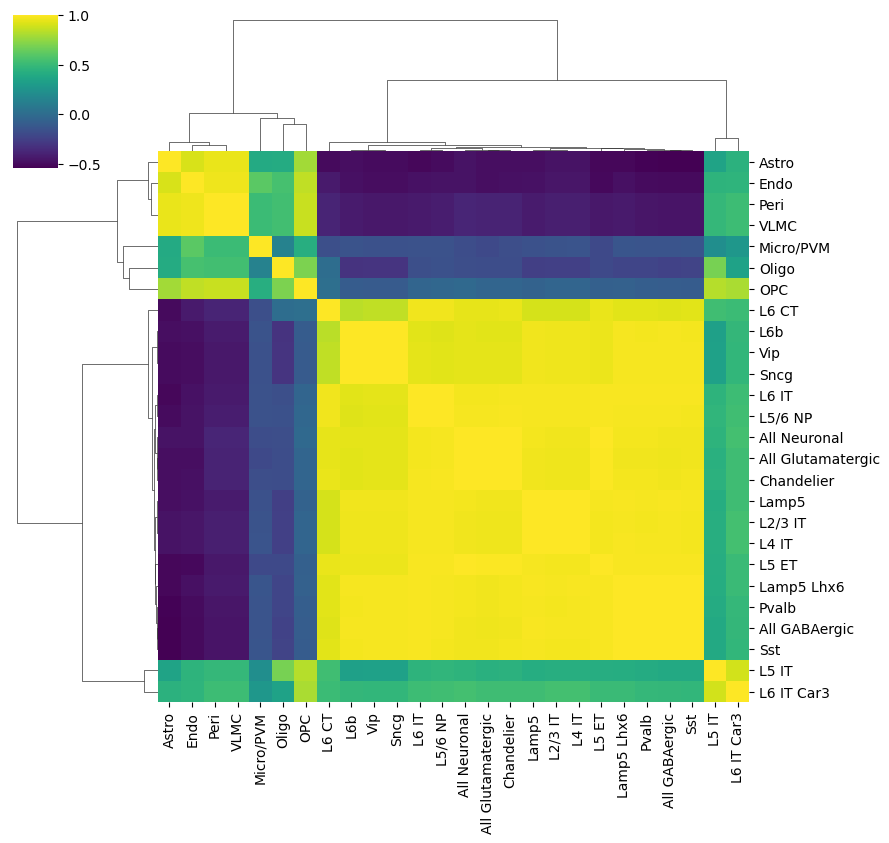

In [17]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(9, 8.5))

# Manually inspect genes

# Filter eigengenes

In [ ]:
ctype_abundance_filt = ctype_abundance_df.loc[:, keep]

In [ ]:
ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L6 IT': 'Deep layer glutamatergic'})

ctype_abundance_filt = ctype_abundance_filt.rename(columns={'L2/3 IT': 'Upper layer glutamatergic'})

In [ ]:
abund_corr_mat = ctype_abundance_filt.corr()
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

In [ ]:
ctype_abundance_filt.to_csv("data/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_filtered.csv")